# FABDEM quickstart — bare-earth DEM, and how it differs from the surface DEM

This notebook downloads a small FABDEM V1-2 subset, visualises the bare-earth
terrain, then downloads the **Copernicus GLO-30** *surface* DEM over the same
area and shows the difference: FABDEM has forest canopy and building heights
removed, which is exactly what you want for flood routing.

> **Licence.** FABDEM is **CC-BY-NC-SA 4.0 (non-commercial)** — `download()`
> emits a `LicenseWarning`. For commercial use, obtain a licence from Fathom.
> FABDEM ships as 0.8–2.4 GB 10° bundles, so this live download takes a few
> minutes; keep the bounding box small.

In [1]:
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

from earthlens.core import EarthLens
from earthlens.biodiversity import LicenseWarning

out = Path(tempfile.mkdtemp(prefix="fabdem-"))
# A small coastal AOI (SE England) with a mix of open ground and settlement.
lat_lim = [50.85, 50.95]
lon_lim = [0.05, 0.15]
print("downloads land under:", out)

2026-08-09 22:01:28 | INFO | pyramids.base.config | Logging is configured.


downloads land under: C:\Users\main\AppData\Local\Temp\fabdem-wyqdgru0


## Download the bare-earth DEM

The non-commercial licence warning is surfaced on download.

In [2]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fabdem_paths = EarthLens(
        data_source="fabdem",
        lat_lim=lat_lim,
        lon_lim=lon_lim,
        path=out / "fabdem",
    ).download()

for w in caught:
    if isinstance(w.message, LicenseWarning):
        print("LicenseWarning:", w.message)
fabdem_paths

[WindowsPath('C:/Users/main/AppData/Local/Temp/fabdem-wyqdgru0/fabdem/fabdem_V1-2.tif')]

## Visualise the terrain

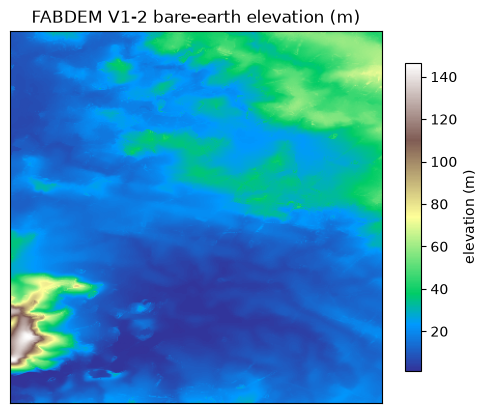

elevation range: 1.3 .. 146.5 m


In [3]:
fabdem = Dataset.read_file(str(fabdem_paths[0]))
nodata = fabdem.no_data_value
nodata = nodata[0] if isinstance(nodata, (list, tuple)) else nodata
bare = fabdem.read_array().astype("float64")
if nodata is not None:
    bare[bare == nodata] = np.nan

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(bare, cmap="terrain")
ax.set_title("FABDEM V1-2 bare-earth elevation (m)")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.8, label="elevation (m)")
plt.show()
print(f"elevation range: {np.nanmin(bare):.1f} .. {np.nanmax(bare):.1f} m")

## Compare against the Copernicus surface DEM

The Copernicus GLO-30 DEM is a *surface* model — it includes tree canopy and
building tops. Subtracting FABDEM (bare-earth) from it leaves the removed
above-ground height (canopy + buildings), which should be roughly zero over open
ground and positive over woodland and built-up areas.

In [4]:
copdem_paths = EarthLens(
    data_source="dem",
    dataset="cop-dem-glo-30",
    lat_lim=lat_lim,
    lon_lim=lon_lim,
    path=out / "copdem",
).download()
copdem_paths

dem/cop-dem-glo-30:   0%|          | 0/1 [00:00<?, ?tile/s]

dem/cop-dem-glo-30: 100%|██████████| 1/1 [00:00<00:00,  1.18tile/s]

dem/cop-dem-glo-30: 100%|██████████| 1/1 [00:00<00:00,  1.18tile/s]

[WindowsPath('C:/Users/main/AppData/Local/Temp/fabdem-wyqdgru0/copdem/Copernicus_DSM_COG_10_N50_00_E000_00_DEM.tif')]

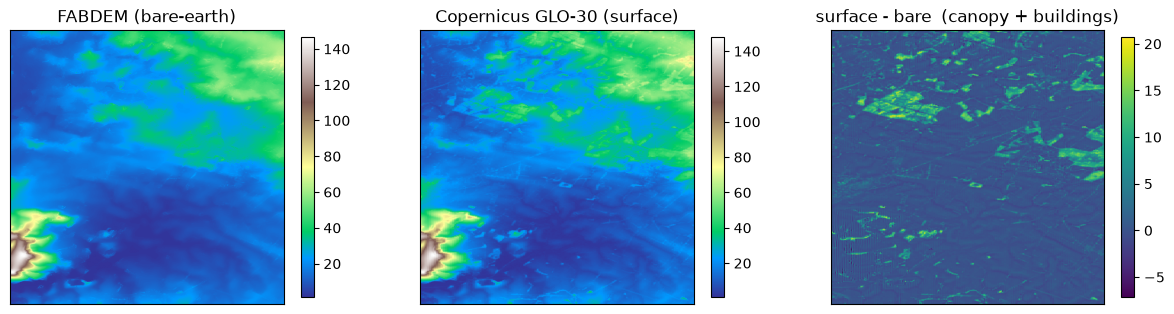

median removed height: 0.09 m; 95th pct: 8.04 m


In [5]:
from pyramids.dataset.merge import merge_rasters

# Align the Copernicus tile(s) onto the FABDEM grid so the arrays subtract cleanly.
aligned = out / "copdem_aligned.tif"
merge_rasters(src=[str(p) for p in copdem_paths], dst=str(aligned), dst_crs=None, resampling="bilinear")
cop = Dataset.read_file(str(aligned)).align(fabdem)
surface = cop.read_array().astype("float64")
surface[surface < -1000] = np.nan

diff = surface - bare  # removed above-ground height (canopy + buildings)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, data, title, cmap in [
    (axes[0], bare, "FABDEM (bare-earth)", "terrain"),
    (axes[1], surface, "Copernicus GLO-30 (surface)", "terrain"),
    (axes[2], diff, "surface - bare  (canopy + buildings)", "viridis"),
]:
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()
print(f"median removed height: {np.nanmedian(diff):.2f} m; 95th pct: {np.nanpercentile(diff, 95):.2f} m")

## Takeaway

FABDEM gives you the terrain surface with vegetation and buildings stripped out —
the bare earth that water actually flows over. The difference map highlights
woodland and settlement, exactly the features that a surface DEM would wrongly
treat as ground in a flood model.